# Cerința 6 — Deep Learning cu TensorFlow

### Enunțul problemei
Construim o **rețea neurală feed-forward** (Fully Connected / Dense) pentru clasificarea binară a tentativelor de șut:
- **Input:** vectorul de caracteristici al unui șut (locație, parte corp, situație, assist, etc.)
- **Output:** probabilitatea că șutul este gol

### Justificarea alegerii — Rețea neurală densă
- Rețelele neuronale pot **captura interacțiuni non-liniare complexe** între features (ex: combinația „colțul careului + contraatac + picior stâng” poate fi mult mai mult decât suma componentelor)
- Spre deosebire de Random Forest care combină arbori independenți, rețeaua neurală **învață reprezentări ierarhice** ale datelor
- Permite **compararea directă** cu modelul MLlib din Cerința 3 pe aceleași date
- **Batch Normalization** și **Dropout** combat overfitting-ul pe dataset-ul dezechilibrat

### Workflow
```
Spark DataFrame → toPandas() → Preprocessing (sklearn) → TF/Keras model → Evaluare → Comparație cu RF MLlib
```

In [1]:
import os
# Notebook-urile stau în subfolderul notebooks/; ne asigurăm că lucrăm din rădăcina proiectului
# (unde se află data/, models/, plots/), astfel încât toate căile relative să funcționeze.
if not os.path.isdir('data') and os.path.isdir(os.path.join('..', 'data')):
    os.chdir('..')
# Directoarele de output trebuie să existe înainte de orice savefig()/save()
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)
print('Working directory:', os.getcwd())

Working directory: /Users/stefan/Documents/football-events-analysis


In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # supress TF warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)

print(f'TensorFlow: {tf.__version__}')
print(f'Keras: {keras.__version__}')
print(f'GPU disponibil: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.16.2
Keras: 3.12.2
GPU disponibil: False


## 6.1 Pregătirea datelor

Folosim Spark doar pentru citirea și preprocesarea inițială, apoi transferăm în Pandas pentru antrenarea cu TensorFlow.

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder \
    .appName('FootballDL') \
    .config('spark.driver.memory', '4g') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('ERROR')

# Citim datele cu Spark
if os.path.exists('data/processed_shots'):
    shots_spark = spark.read.parquet('data/processed_shots')
else:
    shots_spark = spark.read.csv('data/events.csv', header=True, inferSchema=True, nullValue='NA') \
        .filter((col('event_type') == 1) & col('is_goal').isNotNull() &
                col('location').isNotNull() & col('bodypart').isNotNull() &
                col('situation').isNotNull()) \
        .fillna({'assist_method': 0, 'fast_break': 0, 'shot_place': 0, 'side': 1})

feature_cols = ['location', 'bodypart', 'situation', 'assist_method',
                'fast_break', 'shot_place', 'side', 'time']

# Selectăm coloanele necesare și transferăm în Pandas
shots_pd = shots_spark.select(feature_cols + ['is_goal']).dropna().toPandas()
spark.stop()

print(f'Dataset: {len(shots_pd):,} rânduri, {shots_pd.shape[1]} coloane')
print(f'Distribuție target: gol={shots_pd["is_goal"].sum():,} ({shots_pd["is_goal"].mean()*100:.1f}%), '
      f'non-gol={(shots_pd["is_goal"]==0).sum():,}')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/11 21:35:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Dataset: 229,135 rânduri, 9 coloane
Distribuție target: gol=24,441 (10.7%), non-gol=204,694


### Split stratificat, normalizare și ponderi de clasă

Trei pregătiri esențiale pentru o rețea neuronală: **(1)** split 70/15/15 *stratificat* — păstrăm proporția de ~10% goluri în toate seturile; **(2)** `StandardScaler` (medie 0, deviație 1) — gradient descent converge prost pe features cu scale diferite, spre deosebire de arborii din C3 care sunt invarianți la scală; **(3)** `class_weight` — erorile pe goluri (clasa minoritară) cântăresc de ~9× mai mult în funcția de pierdere.

**De reținut:** scaler-ul se antrenează (`fit_transform`) *doar pe train* și se aplică (`transform`) pe val/test — altfel am „scurge" informație din test în antrenare (data leakage).

In [4]:
X = shots_pd[feature_cols].values.astype(np.float32)
y = shots_pd['is_goal'].values.astype(np.float32)

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Normalizare
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Pondere pentru clase dezechilibrate
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg / pos}

print(f'Train:      {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')
print(f'Class weight — 0: {class_weight[0]:.1f}, 1: {class_weight[1]:.1f} (compensare dezechilibru)')

Train:      160,394 | Val: 34,370 | Test: 34,371
Class weight — 0: 1.0, 1: 8.4 (compensare dezechilibru)


## 6.2 Arhitectura rețelei neuronale

```
Input (8 features)
    ↓
Dense(256, ReLU) + BatchNorm + Dropout(0.4)
    ↓
Dense(128, ReLU) + BatchNorm + Dropout(0.3)
    ↓
Dense(64, ReLU) + Dropout(0.2)
    ↓
Dense(1, Sigmoid)  →  P(gol)
```

- **BatchNormalization** — stabilizează antrenarea, reduce sensibilitatea la inițializarea parametrilor
- **Dropout** — dezactivează aleator neuroni în antrenare, prevenind overfitting-ul
- **Sigmoid** la output — produce probabilitate ∈ [0,1]
- **Adam** + **binary_crossentropy** — standard pentru clasificare binară

In [5]:
tf.random.set_seed(42)
np.random.seed(42)

n_features = X_train.shape[1]

# Arhitectură piramidală 256 -> 128 -> 64 -> 1: straturile largi de la intrare învață multe
# combinații de features, cele înguste de la final le comprimă spre decizie.
# Fiecare bloc Dense e urmat de:
# - BatchNormalization: normalizează activațiile batch-ului (medie 0, var 1) -> antrenare stabilă,
#   mai puțin sensibilă la inițializare și la learning rate.
# - Dropout: dezactivează aleator un procent din neuroni la FIECARE pas de antrenare -> neuronii
#   nu se pot baza unii pe alții (anti-co-adaptare) = regularizare. Procent mai mare (0.4) la
#   straturile mari (au mai mulți parametri, risc mai mare de overfit), mai mic spre final.
model = keras.Sequential([
    layers.Input(shape=(n_features,)),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
], name='FootballGoalPredictor')

# - Adam: optimizator cu learning rate adaptiv per parametru (momentum + RMSProp);
#   lr=0.001 e valoarea standard de pornire pentru Adam.
# - binary_crossentropy: loss-ul natural pentru clasificare binară cu sigmoid —
#   penalizează puternic predicțiile încrezătoare dar greșite (log-loss).
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

model.summary()

Model: "FootballGoalPredictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,057 (176.00 KB)

 Trainable params: 44,289 (173.00 KB)

 Non-trainable params: 768 (3.00 KB)

## 6.3 Antrenarea modelului

In [6]:
# EarlyStopping: oprește antrenarea când val_auc nu mai crește timp de 6 epoci (patience)
# și RESTAUREAZĂ ponderile de la cea mai bună epocă (restore_best_weights) — modelul final
# nu e cel din ultima epocă (posibil deja overfit), ci cel mai bun văzut pe validare.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=6,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    # ReduceLROnPlateau: când val_loss stagnează 3 epoci, înjumătățește learning rate-ul (factor=0.5)
    # — pași mai mici ajută la rafinarea convergenței spre finalul antrenării.
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=512,
    validation_data=(X_val, y_val),
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

print(f'\nAntrenare finalizată după {len(history.history["loss"])} epoci.')

Epoch 1/40


  1/314 ━━━━━━━━━━━━━━━━━━━━ 3:35 688ms/step - accuracy: 0.6348 - auc: 0.5089 - loss: 1.6513 - precision: 0.0964 - recall: 0.3019

 22/314 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6485 - auc: 0.5638 - loss: 1.4976 - precision: 0.1303 - recall: 0.4291    

 42/314 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6437 - auc: 0.5894 - loss: 1.4365 - precision: 0.1405 - recall: 0.4794

 63/314 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6434 - auc: 0.6043 - loss: 1.3952 - precision: 0.1466 - recall: 0.5060

...

299/314 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8400 - auc: 0.9637 - loss: 0.3950 - precision: 0.3964 - recall: 0.9656


Epoch 40: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.


314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8411 - auc: 0.9630 - loss: 0.3982 - precision: 0.3989 - recall: 0.9655 - val_accuracy: 0.8397 - val_auc: 0.9635 - val_loss: 0.2498 - val_precision: 0.3965 - val_recall: 0.9640 - learning_rate: 1.5625e-05


Restoring model weights from the end of the best epoch: 39.



Antrenare finalizată după 40 epoci.


### Curbele de antrenare — diagnoza vizuală a antrenării

Urmărim loss/AUC/accuracy pe train vs validare, epocă cu epocă. Curbele apropiate = model sănătos; val-loss care crește în timp ce train-loss scade = overfitting (moment în care EarlyStopping oprește antrenarea și restaurează cele mai bune ponderi).

**De reținut:** scăderile bruște de loss coincid de obicei cu reducerile de learning rate făcute de ReduceLROnPlateau.

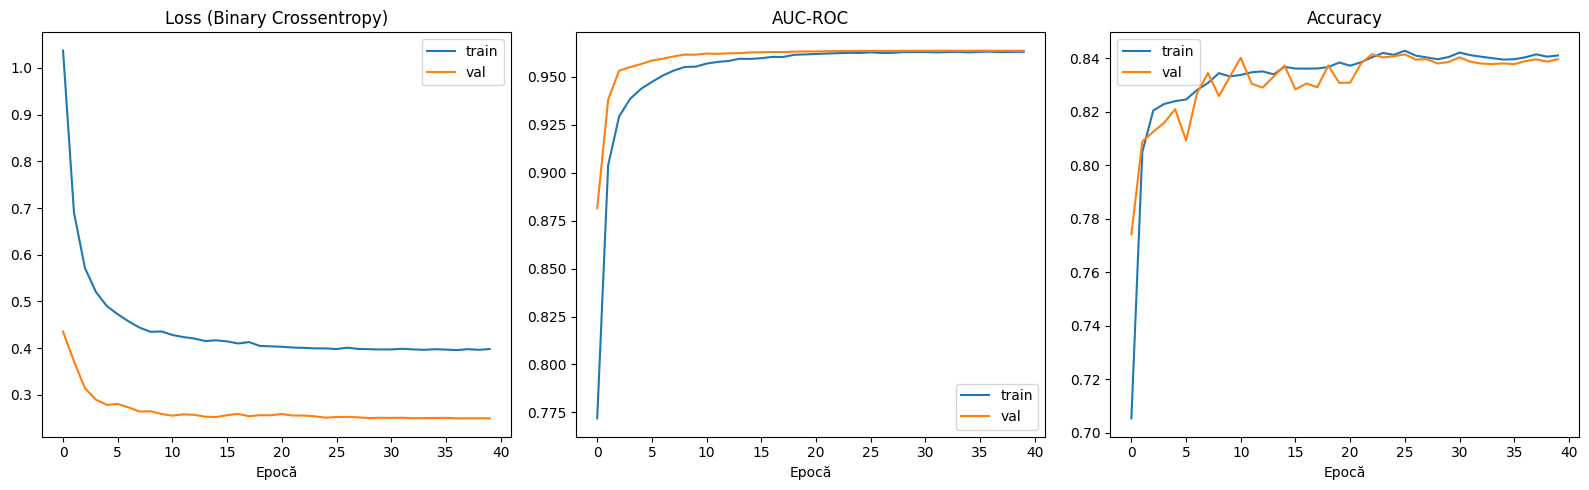

In [7]:
# Curbe de antrenare
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss (Binary Crossentropy)')
axes[0].set_xlabel('Epocă')
axes[0].legend()

axes[1].plot(history.history['auc'],     label='train')
axes[1].plot(history.history['val_auc'], label='val')
axes[1].set_title('AUC-ROC')
axes[1].set_xlabel('Epocă')
axes[1].legend()

axes[2].plot(history.history['accuracy'],     label='train')
axes[2].plot(history.history['val_accuracy'], label='val')
axes[2].set_title('Accuracy')
axes[2].set_xlabel('Epocă')
axes[2].legend()

plt.tight_layout()
plt.savefig('plots/fig_tf_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 6.4 Evaluarea modelului pe setul de test

In [8]:
# Predicții pe test set
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

test_loss, test_acc, test_auc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)
test_f1 = f1_score(y_test, y_pred, average='weighted')

print('=== Metrici TensorFlow Neural Network (Test Set) ===')
print(f'  Loss (BCE) : {test_loss:.4f}')
print(f'  AUC-ROC    : {test_auc:.4f}')
print(f'  Accuracy   : {test_acc:.4f}')
print(f'  Precision  : {test_prec:.4f}')
print(f'  Recall     : {test_rec:.4f}')
print(f'  F1-Score   : {test_f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Nu gol', 'Gol']))

=== Metrici TensorFlow Neural Network (Test Set) ===
  Loss (BCE) : 0.2477
  AUC-ROC    : 0.9640
  Accuracy   : 0.8417
  Precision  : 0.3994
  Recall     : 0.9621
  F1-Score   : 0.8671

              precision    recall  f1-score   support

      Nu gol       0.99      0.83      0.90     30705
         Gol       0.40      0.96      0.56      3666

    accuracy                           0.84     34371
   macro avg       0.70      0.89      0.73     34371
weighted avg       0.93      0.84      0.87     34371



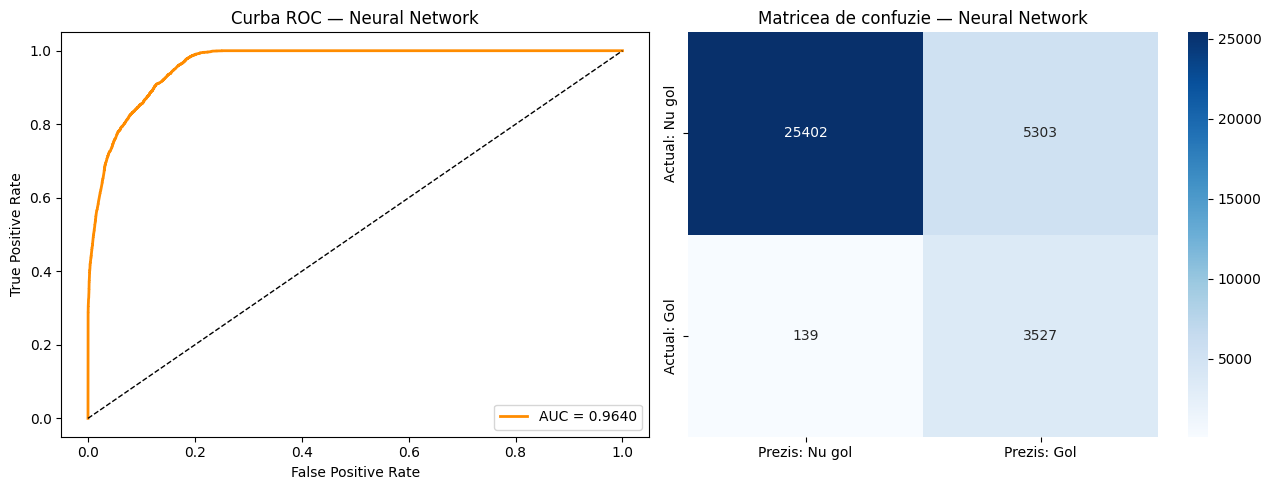

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curba ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_val:.4f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curba ROC — Neural Network')
axes[0].legend()

# Matricea de confuzie
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prezis: Nu gol', 'Prezis: Gol'],
            yticklabels=['Actual: Nu gol', 'Actual: Gol'], ax=axes[1])
axes[1].set_title('Matricea de confuzie — Neural Network')

plt.tight_layout()
plt.savefig('plots/fig_tf_roc_cm.png', dpi=120, bbox_inches='tight')
plt.show()

### Diagnoză pe clase: distribuția probabilităților + Precision-Recall

**De ce aceste grafice:** Pe un dataset dezechilibrat (~10-12% goluri), **AUC-ROC și accuracy pot fi înșelător de optimiste** — un model care prezice mereu „nu e gol" obține deja ~90% accuracy. Două instrumente mai oneste:

- **Distribuția probabilităților prezise pe clase** — arată cât de bine *separă* modelul cele două clase. Ideal: golurile au probabilități împinse spre 1, ne-golurile spre 0; zona de suprapunere = incertitudinea modelului.
- **Curba Precision-Recall** — spre deosebire de ROC (care folosește *true negative rate*, dominat de clasa majoritară), PR se concentrează pe clasa pozitivă (goluri). *Average Precision* (AP) și linia de baseline (= proporția pozitivelor) arată cât de greu e de fapt task-ul. Analogie backend: e diferența dintre a măsura *uptime global* (înșelător când 90% din trafic e trivial) vs *latența pe request-urile critice*.

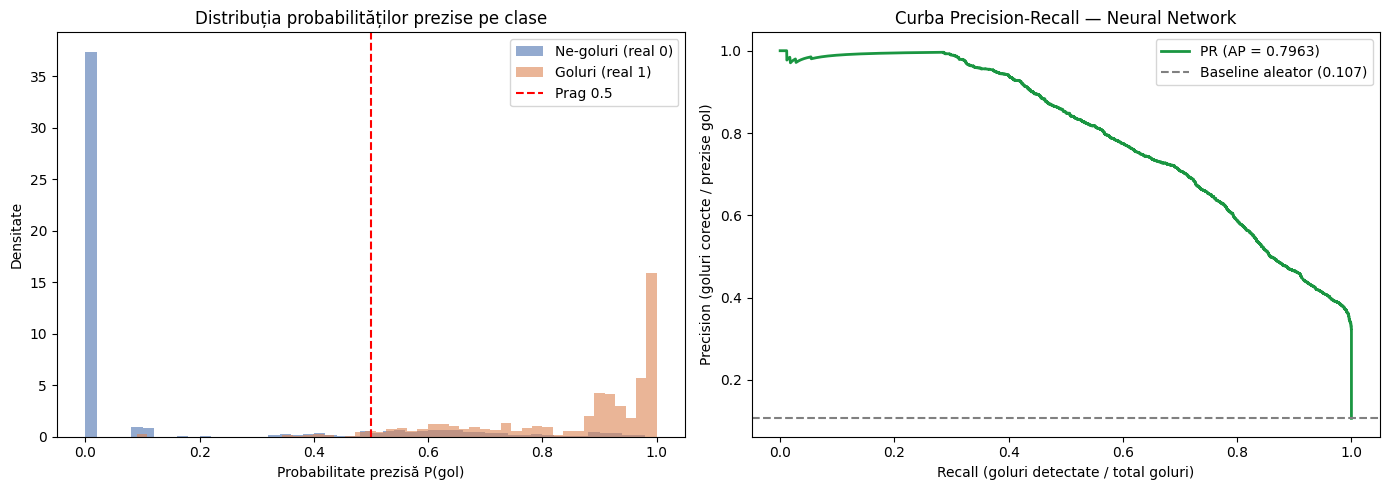

Average Precision (AP): 0.7963  |  baseline aleator: 0.1067


In [10]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) Distribuția probabilităților prezise, separat pe cele două clase reale
axes[0].hist(y_prob[y_test == 0], bins=50, alpha=0.6, density=True,
             label='Ne-goluri (real 0)', color='#4c72b0')
axes[0].hist(y_prob[y_test == 1], bins=50, alpha=0.6, density=True,
             label='Goluri (real 1)', color='#dd8452')
axes[0].axvline(0.5, color='red', linestyle='--', label='Prag 0.5')
axes[0].set_xlabel('Probabilitate prezisă P(gol)')
axes[0].set_ylabel('Densitate')
axes[0].set_title('Distribuția probabilităților prezise pe clase')
axes[0].legend()

# (2) Curba Precision-Recall (mai informativă decât ROC pe date dezechilibrate)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
baseline = y_test.mean()   # precision a unui clasificator aleator = proporția pozitivelor
axes[1].plot(rec_curve, prec_curve, color='#1a9641', lw=2, label=f'PR (AP = {ap:.4f})')
axes[1].axhline(baseline, color='gray', linestyle='--',
                label=f'Baseline aleator ({baseline:.3f})')
axes[1].set_xlabel('Recall (goluri detectate / total goluri)')
axes[1].set_ylabel('Precision (goluri corecte / prezise gol)')
axes[1].set_title('Curba Precision-Recall — Neural Network')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/fig_tf_prob_dist_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Average Precision (AP): {ap:.4f}  |  baseline aleator: {baseline:.4f}')

## 6.5 Compararea Neural Network vs Random Forest (MLlib)

Comparăm metricile obținute de cele două abordări pe același task de clasificare.

In [11]:
import joblib

# Valorile RF măsurate în Cerința 3 (rularea finală, test set, seed=42)
comparison = pd.DataFrame({
    'Metrică': ['AUC-ROC', 'Accuracy', 'F1-Score (wgt)'],
    'Random Forest (MLlib)': [0.9545, 0.9298, 0.9159],
    'Neural Network (TF)':   [test_auc, test_acc, test_f1]
})

print(comparison.to_string(index=False))

# Salvăm artefactele necesare pentru inferență
os.makedirs('models', exist_ok=True)
model.save('models/tf_goal_predictor.keras')
# Scaler-ul TREBUIE salvat împreună cu modelul: la inferență, datele noi trebuie
# normalizate cu EXACT aceiași parametri (medie/deviație standard) învățați pe train.
# Altfel modelul primește input pe altă scară decât cea pe care a fost antrenat.
joblib.dump(scaler, 'models/tf_scaler.joblib')

print('\nModel TensorFlow salvat în : models/tf_goal_predictor.keras')
print('Scaler salvat în           : models/tf_scaler.joblib')

       Metrică  Random Forest (MLlib)  Neural Network (TF)
       AUC-ROC                 0.9545             0.963996
      Accuracy                 0.9298             0.841669
F1-Score (wgt)                 0.9159             0.867116

Model TensorFlow salvat în : models/tf_goal_predictor.keras
Scaler salvat în           : models/tf_scaler.joblib


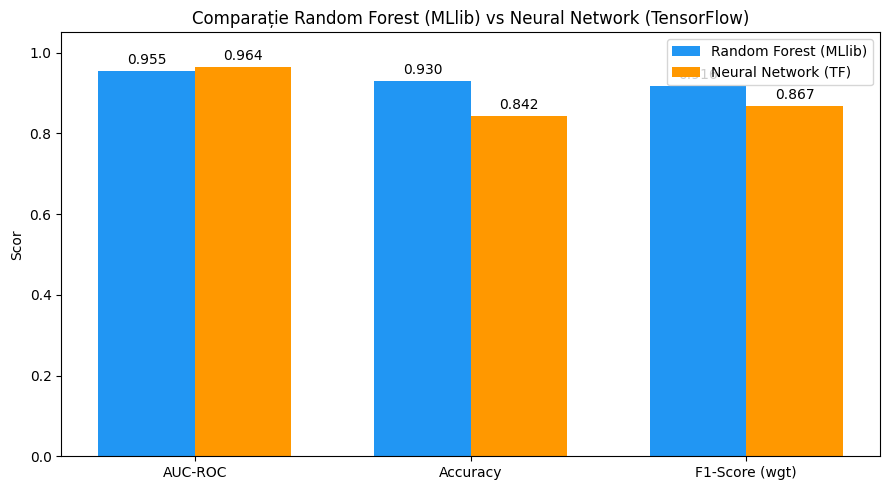

In [12]:
metrics = comparison['Metrică'].tolist()
rf_vals = comparison['Random Forest (MLlib)'].tolist()
nn_vals = comparison['Neural Network (TF)'].tolist()

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, rf_vals, width, label='Random Forest (MLlib)', color='#2196F3')
bars2 = ax.bar(x + width/2, nn_vals, width, label='Neural Network (TF)',   color='#FF9800')

ax.bar_label(bars1, fmt='{:.3f}', padding=3)
ax.bar_label(bars2, fmt='{:.3f}', padding=3)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Scor')
ax.set_title('Comparație Random Forest (MLlib) vs Neural Network (TensorFlow)')
ax.legend()

plt.tight_layout()
plt.savefig('plots/fig_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()